In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
gdf = gpd.read_file("AssignmentData/TickBites_Dec16/NL_TickBites_Dec16_RD_New.shp")
gdf.head()

,OBJECTID,field_1,field_2,field_3,field_4,field_5,field_6,field_7,field_8,field_9,field_10,field_11,field_12,field_13,field_14,field_15,geometry
0,1,1,NaT,NaT,387000.000000,174000.000000,None,None,None,None,None,heide,wandelen,None,1000,De rode kring openbaarde zich in februari van ...,POINT (174000 387000)
1,2,2,2002-01-01,2012-06-05,427805.600595,60001.108122,3252LE,None,Goedereede,Goeree-Overflakkee,Zuid-Holland,tuin,tuinieren,1960,18,zonnen,POINT (60001.108 427805.601)
2,3,3,2002-01-01,2012-07-14,566788.639714,198817.497861,None,None,None,None,None,tuin,spelen,None,18,None,POINT (198817.498 566788.64)
3,4,5,2002-07-01,2012-03-31,511841.215297,202893.287001,8061RV,None,Hasselt,Zwartewaterland,Overijssel,tuin-weiland-moerasgebied,tuinieren,1960,14,koeien ophalen,POINT (202893.287 511841.215)
4,5,7,2003-01-01,2013-01-27,536045.842573,213043.090819,None,None,Zwolle,Zwolle,Overijssel,bos,wandelen,1965,13,None,POINT (213043.091 536045.843)


In [3]:
gdf.rename({
    "field_1": "ID",
    "field_2": "reporting_date",
    "field_3": "tick_bite_date",
    "field_4": "longitude",
    "field_5": "latitude",
    "field_6": "postal_code",
    "field_7": "Unknown_1",
    "field_8": "city",
    "field_9": "municipality",
    "field_10": "province",
    "field_11": "environment",
    "field_12": "activity",
    "field_13": "year_of_birth",
    "field_14": "zoom",
    "field_15": "general_remarks",

}, axis=1, inplace=True)

In [4]:
ede_shape  = gpd.read_file("Ede_shapefile/Ede_shape.shp")
ede_shape.head()

,GM_CODE,GM_NAAM,WATER,OAD,STED,AANT_INW,AANT_MAN,AANT_VROUW,P_00_14_JR,P_15_24_JR,...,P_HH_M_K,GEM_HH_GR,P_WEST_AL,P_N_W_AL,P_MAROKKO,P_ANT_ARU,P_SURINAM,P_TURKIJE,P_OVER_NW,geometry
0,GM0228,Ede,NEE,1525,2,114682,56689,57993,18,14,...,35,2.3,7,8,2,0,1,2,4,"POLYGON ((182010.005 462674.48, 182247.789 462..."


In [5]:
ede_shape.crs = "EPSG:28992"

In [6]:
gdf_ede_1 = gpd.sjoin(gdf, ede_shape, how="inner", predicate="within")
# gdf_ede_2 = gpd.sjoin(gdf, ede_shape, how="inner", predicate="intersects")

In [7]:
gdf_ede_1.head()

,OBJECTID,ID,reporting_date,tick_bite_date,longitude,latitude,postal_code,Unknown_1,city,municipality,...,P_HH_Z_K,P_HH_M_K,GEM_HH_GR,P_WEST_AL,P_N_W_AL,P_MAROKKO,P_ANT_ARU,P_SURINAM,P_TURKIJE,P_OVER_NW
17,18,20,2006-04-09,2006-04-09,451000.0,173000.0,None,None,Ede,Ede,...,30,35,2.3,7,8,2,0,1,2,4
36,37,40,2006-04-23,2006-04-23,451000.0,173000.0,None,None,Ede,Ede,...,30,35,2.3,7,8,2,0,1,2,4
58,59,62,2006-05-04,2006-05-04,451000.0,173000.0,None,None,Ede,Ede,...,30,35,2.3,7,8,2,0,1,2,4
240,241,247,2006-06-03,2006-06-03,451000.0,173000.0,None,None,Ede,Ede,...,30,35,2.3,7,8,2,0,1,2,4
325,326,334,2006-06-06,2006-06-06,451000.0,173000.0,None,None,Ede,Ede,...,30,35,2.3,7,8,2,0,1,2,4


In [9]:
gdf_ede_1.to_file("ede_reports-2.geojson", driver="GEOJSON")

In [2]:
gdf = gpd.read_file("ede_reports.geojson")
gdf.head()

,OBJECTID,ID,reporting_date,tick_bite_date,longitude,latitude,postal_code,Unknown_1,city,municipality,...,P_HH_M_K,GEM_HH_GR,P_WEST_AL,P_N_W_AL,P_MAROKKO,P_ANT_ARU,P_SURINAM,P_TURKIJE,P_OVER_NW,geometry
0,18,20,2006-04-09,2006-04-09,451000.0,173000.0,None,None,Ede,Ede,...,35,2.3,7,8,2,0,1,2,4,POINT (173000 451000)
1,37,40,2006-04-23,2006-04-23,451000.0,173000.0,None,None,Ede,Ede,...,35,2.3,7,8,2,0,1,2,4,POINT (173000 451000)
2,59,62,2006-05-04,2006-05-04,451000.0,173000.0,None,None,Ede,Ede,...,35,2.3,7,8,2,0,1,2,4,POINT (173000 451000)
3,241,247,2006-06-03,2006-06-03,451000.0,173000.0,None,None,Ede,Ede,...,35,2.3,7,8,2,0,1,2,4,POINT (173000 451000)
4,326,334,2006-06-06,2006-06-06,451000.0,173000.0,None,None,Ede,Ede,...,35,2.3,7,8,2,0,1,2,4,POINT (173000 451000)


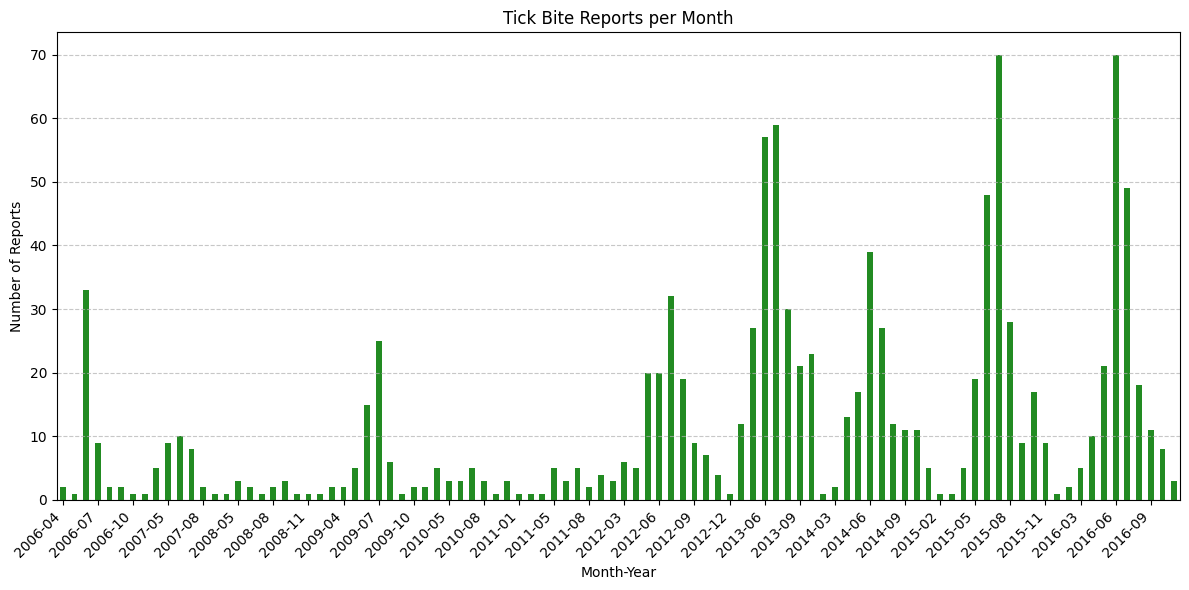

In [3]:
import matplotlib.pyplot as plt

gdf["reporting_date"] = pd.to_datetime(gdf["reporting_date"])
gdf['month_year'] = gdf['reporting_date'].dt.to_period('M')
monthly_counts = gdf.groupby("month_year").size().sort_index()

plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='bar', color='forestgreen')

plt.title("Tick Bite Reports per Month")
plt.xlabel("Month-Year")
plt.ylabel("Number of Reports")

# Reduce number of xticks
xticks = plt.gca().get_xticks()
labels = plt.gca().get_xticklabels()
plt.xticks(xticks[::3], [label.get_text() for i, label in enumerate(labels) if i % 3 == 0], rotation=45, ha='right')

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [4]:
gdf["month"] = gdf["reporting_date"].dt.month
(gdf.groupby("month").size() / gdf.groupby("month").size().sum()) * 100

month
1      0.090580
2      0.271739
3      1.902174
4      5.434783
5     11.775362
6     27.173913
7     26.268116
8     11.231884
9      6.612319
10     6.884058
11     2.083333
12     0.271739
dtype: float64

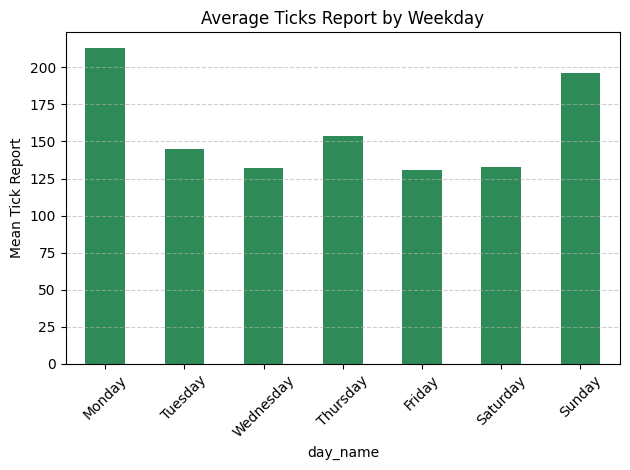

In [5]:
# Get weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

gdf['day_name'] = pd.to_datetime(gdf["reporting_date"]).dt.day_name()
# Compute mean tick count per event
mean_ticks = gdf.groupby("day_name").size().reindex(weekday_order)

mean_ticks.plot(kind="bar", color="seagreen")
plt.title("Average Ticks Report by Weekday")
plt.ylabel("Mean Tick Report")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [5]:
import pandas as pd
import numpy as np

# Replace "None" strings and other non-numeric values with NaN
gdf["year_of_birth_clean"] = pd.to_numeric(gdf["year_of_birth"], errors="coerce")

# If you need it as a datetime (e.g., 1980 → 1980-01-01)
gdf["date_of_birth"] = pd.to_datetime(gdf["year_of_birth_clean"], format="%Y", errors="coerce")

# (Optional) Calculate age at time of tick bite
gdf["tick_bite_date"] = pd.to_datetime(gdf["reporting_date"], errors="coerce")
gdf["age_at_bite"] = gdf["tick_bite_date"].dt.year - gdf["date_of_birth"].dt.year

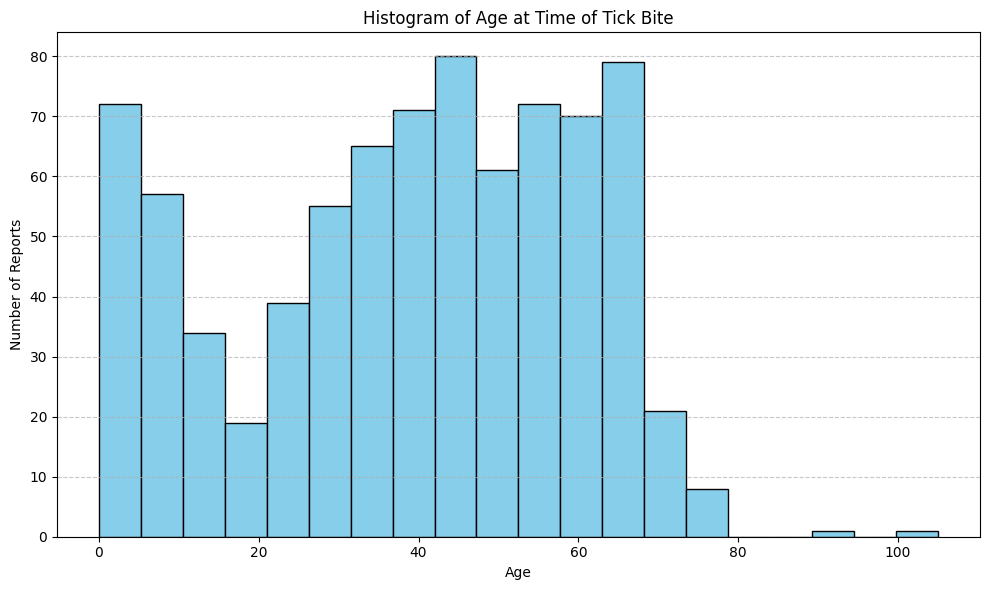

In [6]:
import matplotlib.pyplot as plt

# Drop NaN values for plotting
age_data = gdf["age_at_bite"].dropna()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(age_data, bins=20, color='skyblue', edgecolor='black')

plt.title("Histogram of Age at Time of Tick Bite")
plt.xlabel("Age")
plt.ylabel("Number of Reports")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
gdf["age_at_bite"] = gdf["age_at_bite"].dropna()

In [8]:
gdf = gdf[gdf["age_at_bite"]>0]

In [9]:
# Define bins and labels
bins = list(range(0, 100, 10)) + [float('inf')]  # [0, 10, 20, ..., 90, inf]
labels = [f"{i}-{i+10}" for i in range(0, 90, 10)] + ["90+"]

# Categorize age values into bins
gdf["age_group"] = pd.cut(gdf["age_at_bite"], bins=bins, labels=labels, right=False)

# Display count per group (optional)
print(gdf["age_group"].value_counts().sort_index())

age_group
0-10     107
10-20     58
20-30     75
30-40    137
40-50    124
50-60    140
60-70    132
70-80     20
80-90      0
90+        2
Name: count, dtype: int64


In [10]:
(gdf["age_group"].value_counts().sort_index() / len(gdf)) * 100

age_group
0-10     13.459119
10-20     7.295597
20-30     9.433962
30-40    17.232704
40-50    15.597484
50-60    17.610063
60-70    16.603774
70-80     2.515723
80-90     0.000000
90+       0.251572
Name: count, dtype: float64

In [11]:
def categorize_activity(activity):
    if activity is None:
        return "Unknown"
    
    a = activity.lower()
    
    if "wandelen" in a:
        return "Walking"
    elif "honduitlaten" in a or "hond uitlaten" in a:
        return "Dog walking"
    elif "tuinieren" in a:
        return "Gardening"
    elif "spelen" in a:
        return "Playing"
    elif "picknicken" in a or "picknick" in a:
        return "Picnicking"
    elif "groenbeheer" in a:
        return "Green maintenance"
    elif "weetniet" in a or "weet niet" in a:
        return "Unknown"
    elif "anders" in a:
        return "Other"
    else:
        return "Other"

gdf["activity_grouped"] = gdf["activity"].apply(categorize_activity)

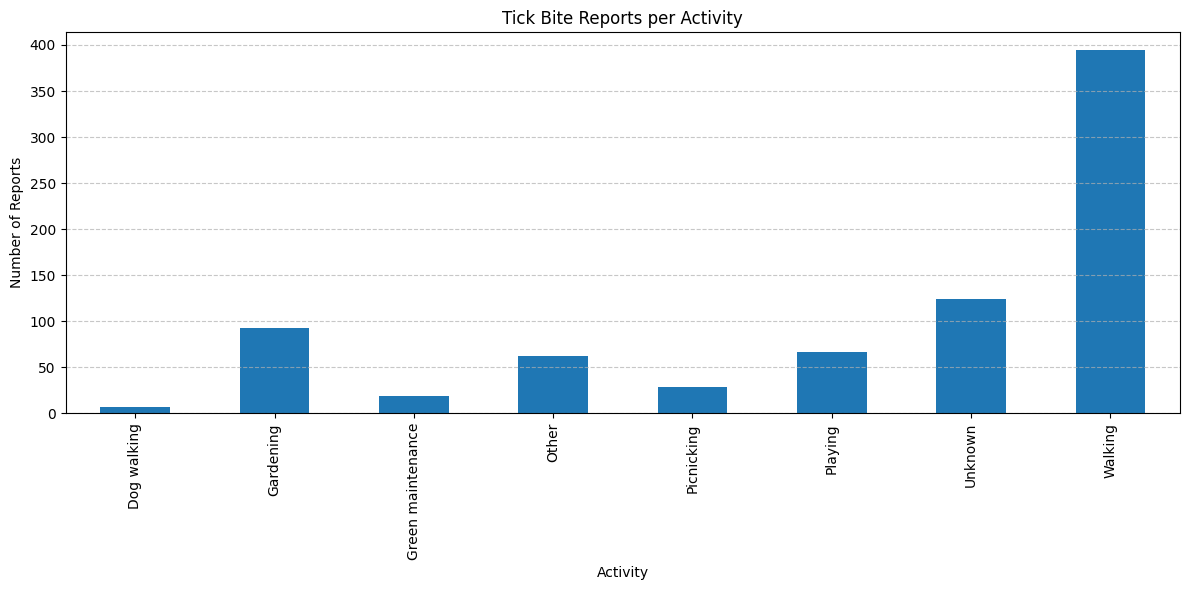

In [12]:
import matplotlib.pyplot as plt

activity_count = gdf.groupby("activity_grouped").size().sort_index()

plt.figure(figsize=(12, 6))
activity_count.plot(kind='bar')

plt.title("Tick Bite Reports per Activity")
plt.xlabel("Activity")
plt.ylabel("Number of Reports")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [13]:
(activity_count / len(gdf)) * 100

activity_grouped
Dog walking           0.880503
Gardening            11.698113
Green maintenance     2.389937
Other                 7.798742
Picnicking            3.647799
Playing               8.427673
Unknown              15.597484
Walking              49.559748
dtype: float64

In [14]:
def categorize_environment(env):
    if env is None:
        return "Unknown"
    
    e = env.lower()
    
    if "tuin" in e:
        return "Garden"
    elif "bos" in e:
        return "Forest"
    elif "heide" in e:
        return "Heather"
    elif "weiland" in e:
        return "Pasture"
    elif "stadspark" in e:
        return "Urban Park"
    elif "duinen" in e:
        return "Dunes"
    elif "moerasgebied" in e:
        return "Wetlands"
    elif "weet niet" in e or "weetniet" in e:
        return "Unknown"
    elif "anders" in e:
        return "Other"
    else:
        return "Other"

gdf["environment_grouped"] = gdf["environment"].apply(categorize_environment)

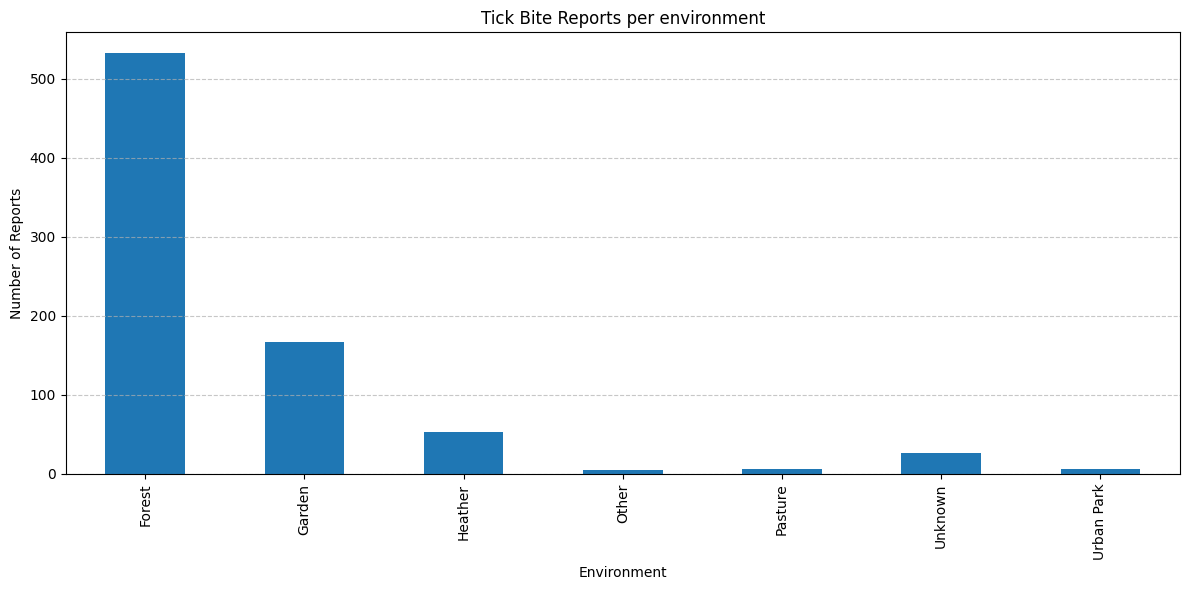

In [15]:
import matplotlib.pyplot as plt

activity_count = gdf.groupby("environment_grouped").size().sort_index()

plt.figure(figsize=(12, 6))
activity_count.plot(kind='bar')

plt.title("Tick Bite Reports per environment")
plt.xlabel("Environment")
plt.ylabel("Number of Reports")

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [16]:
(activity_count / len(gdf)) * 100

environment_grouped
Forest        66.918239
Garden        21.006289
Heather        6.666667
Other          0.628931
Pasture        0.754717
Unknown        3.270440
Urban Park     0.754717
dtype: float64

<Axes: >

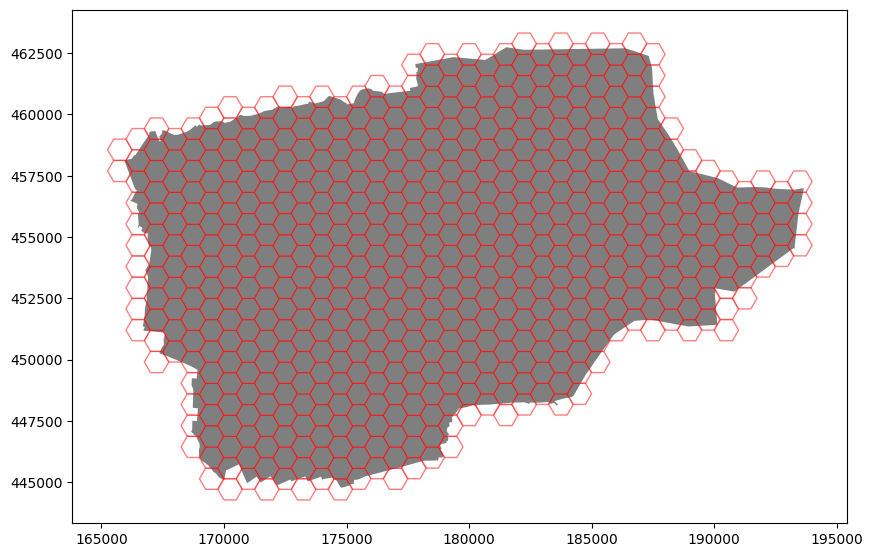

In [19]:
import geopandas as gpd
import geohexgrid as ghg

# # Load New Zealand territorial authorities projected in EPSG 2193 (NZTM)
neth = gpd.read_file("Ede_shapefile/Ede_shape.shp")
neth.crs = "EPSG:28992"

# Cover it minimally with hexagons of circumradius 10 kilometres
grid = ghg.make_grid_from_gdf(neth, R=500)

# # Plot
base = neth.to_crs("EPSG:28992").plot(color="black", figsize=(10, 10), aspect="equal")
grid.plot(ax=base, color="white", edgecolor="red", alpha=0.5)

In [21]:
grid.head()

,cell_id,geometry
5,"226,1028","POLYGON ((169250 444704.045, 169750 444704.045..."
6,"227,1027","POLYGON ((170000 444271.032, 170500 444271.032..."
7,"228,1028","POLYGON ((170750 444704.045, 171250 444704.045..."
8,"229,1027","POLYGON ((171500 444271.032, 172000 444271.032..."
9,"230,1028","POLYGON ((172250 444704.045, 172750 444704.045..."


<Axes: >

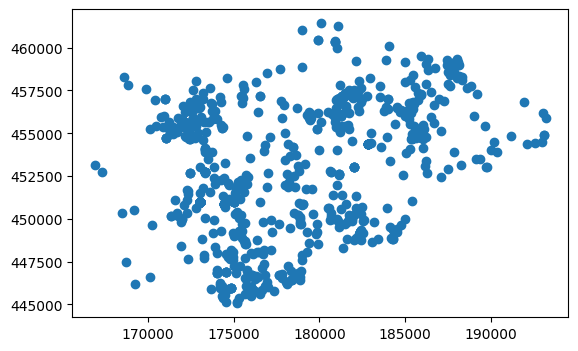

In [24]:
gdf.plot()

In [33]:
if 'index_right' in gdf.columns:
    gdf = gdf.drop(columns='index_right')
if 'index_right' in grid.columns:
    grid = grid.drop(columns='index_right')

In [34]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Ensure both GeoDataFrames use the same CRS
gdf = gdf.to_crs(grid.crs)

# Perform spatial join: assign each point to a hex cell
joined = gpd.sjoin(gdf, grid, how="inner", predicate="within")

# Count the number of points in each hex (using the grid's index or ID)
hex_counts = joined.groupby(joined.index_right).size()

# Add counts to the original grid GeoDataFrame
grid["tick_count"] = grid.index.map(hex_counts).fillna(0).astype(int)

/home/saheel/Documents/ITC/coursework/quartile-4/Spatio-Temporal-Analysis/Group-Assignment/env/lib/python3.12/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 50 classes. Setting k to 11.
  self.bins = quantile(y, k=k)


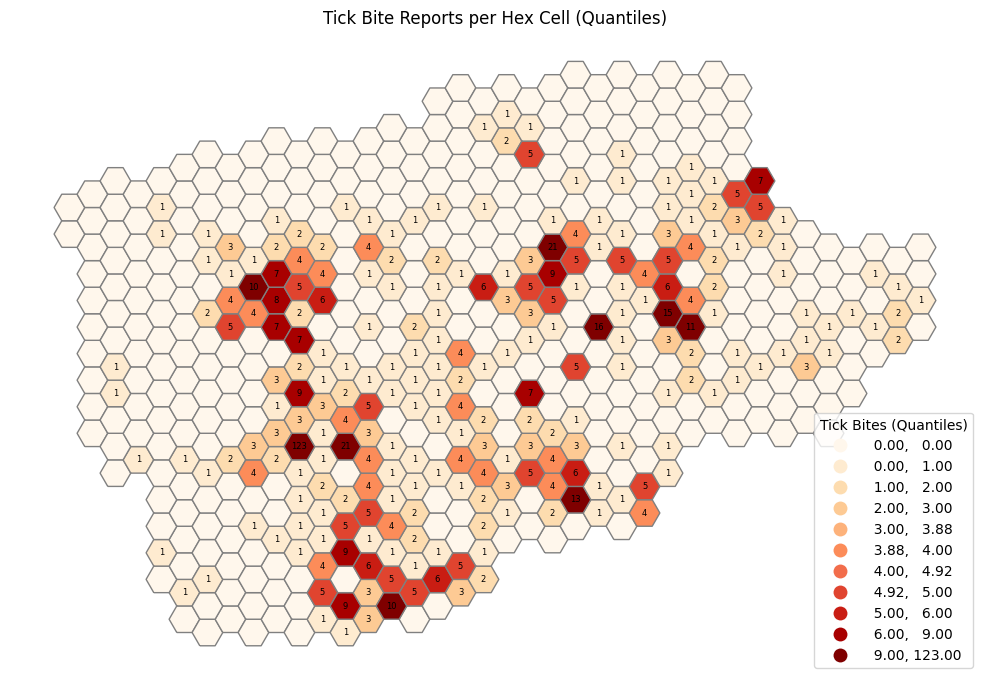

In [44]:
import mapclassify
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Plot with quantile-based classification
grid.plot(
    column="tick_count",
    scheme="Quantiles",
    k=50,  # Number of quantile classes
    cmap="OrRd",
    edgecolor="grey",
    legend=True,
    ax=ax,
    legend_kwds={"title": "Tick Bites (Quantiles)"}
)

# Annotate each hex cell with the tick count at the centroid
for idx, row in grid.iterrows():
    count = row["tick_count"]
    if count > 0:  # Optional: skip empty cells
        x, y = row["geometry"].centroid.coords[0]
        ax.text(
            x, y,
            str(int(count)),  # round/convert if needed
            ha='center', va='center',
            fontsize=6,
            color='black'
        )

plt.title("Tick Bite Reports per Hex Cell (Quantiles)")
plt.axis("off")
plt.tight_layout()
plt.savefig("hexmap-ede.png", dpi=300)
plt.show()


In [1]:
grid.crs

NameError: name 'grid' is not defined

In [46]:
grid.to_file("tick_bites_density_ede.geojson", driver="GEOJSON")